# E-Commerce & Marketing Data Analysis Assignment

Do datasets use ho rahe hain:
- Customer Behavior Data (Kaggle: uom190346a/e-commerce-customer-behavior-dataset) — customer-level
- Marketing Campaign Data (Hugging Face: alsayed7/marketing_dataset) — campaign-level

Data mein kuch columns nahi hain jo assignment maangta hai. Jahan bhi missing hai, code print karega aur closest proxy use karega:
- Country -> City / Location column use kiya
- Individual product name -> Campaign_Name (category-level, product-level nahi)
- Review count -> nahi hai, sirf Average Rating hai
- Likes -> available nahi, skip kiya
- Duration -> available nahi, skip kiya


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


In [3]:
CUSTOMER_FILE = "Ecommerce_Customer_Behavior.csv"
MARKETING_FILE = "marketing_data.csv"


## Load Datasets

In [4]:
def load_csv_safe(path, name):
    try:
        df = pd.read_csv(path)
        print(f"{name} loaded — shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"{name} not found at '{path}'. File isi folder mein rakho ya path change karo.")
        return None

df_cust_raw = load_csv_safe(CUSTOMER_FILE, "Customer Behavior Dataset")
df_camp_raw = load_csv_safe(MARKETING_FILE, "Marketing Campaign Dataset")


Customer Behavior Dataset not found at 'Ecommerce_Customer_Behavior.csv'. File isi folder mein rakho ya path change karo.
Marketing Campaign Dataset loaded — shape: (2000, 13)


In [5]:
if df_cust_raw is not None:
    print(list(df_cust_raw.columns))
    display(df_cust_raw.head())


In [6]:
if df_camp_raw is not None:
    print(list(df_camp_raw.columns))
    display(df_camp_raw.head())


['Campaign_ID', 'Campaign_Name', 'Marketing_Channel', 'Start_Date', 'End_Date', 'Impressions', 'Clicks', 'Conversions', 'Total_Spend', 'Revenue_Generated', 'Location', 'Age_Group', 'Gender']


,Campaign_ID,Campaign_Name,Marketing_Channel,Start_Date,End_Date,Impressions,Clicks,Conversions,Total_Spend,Revenue_Generated,Location,Age_Group,Gender
0,CMP1,Seasonal Steals,Influencer Marketing,2022-08-01,2024-04-26,22068.8,3283.2,2155.2,2316.656,8879.568,Baia Mare,25-34,Male
1,CMP2,Cart to Couch,Influencer Marketing,2022-09-18,2024-05-12,32849.6,3307.2,3164.8,7114.128,17302.032,Baia Mare,25-34,Male
2,CMP3,Deal of the Day,Paid Ads,2022-07-26,2024-04-07,12748.8,7494.4,7334.4,3358.448,4892.416,Galați,45-54,Female
3,CMP4,Shop & Share,Paid Ads,2022-08-21,2024-04-26,40196.8,21150.4,3032.0,4426.976,16548.544,Galați,18-24,Male
4,CMP5,Seasonal Steals,Paid Ads,2023-03-04,2024-11-04,4030.4,2806.4,2556.8,2331.776,3538.224,Galați,45-54,Male


## Data Cleaning & Standardization

In [7]:
cust_rename_map = {
    "Customer ID": "customer_id",
    "Gender": "gender",
    "Age": "age",
    "City": "city",
    "Membership Type": "membership_type",
    "Total Spend": "total_spend",
    "Items Purchased": "items_purchased",
    "Average Rating": "avg_rating",
    "Discount Applied": "discount_applied",
    "Days Since Last Purchase": "days_since_last_purchase",
    "Satisfaction Level": "satisfaction_level",
}

df_cust = None
if df_cust_raw is not None:
    df_cust = df_cust_raw.copy()
    missing_cols = [c for c in cust_rename_map if c not in df_cust.columns]
    if missing_cols:
        print("Columns not found:", missing_cols)
        print("Actual columns:", list(df_cust.columns))
    df_cust = df_cust.rename(columns=cust_rename_map)

    if "gender" in df_cust.columns:
        df_cust["gender"] = df_cust["gender"].astype(str).str.strip().str.title()

    if "age" in df_cust.columns:
        bins = [0, 25, 45, 200]
        labels = ["Young", "Adult", "Senior"]
        df_cust["age_category"] = pd.cut(df_cust["age"], bins=bins, labels=labels)

    print("Customer dataset cleaned. Columns:", list(df_cust.columns))


In [8]:
camp_rename_map = {
    "Campaign_ID": "campaign_id",
    "Campaign_Name": "campaign_name",
    "Marketing_Channel": "channel",
    "Start_Date": "start_date",
    "End_Date": "end_date",
    "Impressions": "views",
    "Clicks": "clicks",
    "Conversions": "conversions",
    "Total_Spend": "campaign_spend",
    "Revenue_Generated": "revenue",
    "Location": "location",
    "Age_Group": "age_group",
    "Gender": "gender",
}

df_camp = None
if df_camp_raw is not None:
    df_camp = df_camp_raw.copy()
    missing_cols = [c for c in camp_rename_map if c not in df_camp.columns]
    if missing_cols:
        print("Columns not found:", missing_cols)
        print("Actual columns:", list(df_camp.columns))
    df_camp = df_camp.rename(columns=camp_rename_map)

    if "gender" in df_camp.columns:
        df_camp["gender"] = df_camp["gender"].astype(str).str.strip().str.title()

    if "start_date" in df_camp.columns:
        df_camp["start_date"] = pd.to_datetime(df_camp["start_date"], errors="coerce")
    if "end_date" in df_camp.columns:
        df_camp["end_date"] = pd.to_datetime(df_camp["end_date"], errors="coerce")

    if {"views", "clicks"}.issubset(df_camp.columns):
        df_camp["ctr_percent"] = (df_camp["clicks"] / df_camp["views"]) * 100
        df_camp["engagement_rate"] = df_camp["clicks"] / df_camp["views"]

    print("Likes column not available in this dataset — skipped wherever asked.")
    print("Marketing dataset cleaned. Columns:", list(df_camp.columns))


Likes column not available in this dataset — skipped wherever asked.
Marketing dataset cleaned. Columns: ['campaign_id', 'campaign_name', 'channel', 'start_date', 'end_date', 'views', 'clicks', 'conversions', 'campaign_spend', 'revenue', 'location', 'age_group', 'gender', 'ctr_percent', 'engagement_rate']


# Customer Analysis

Q1. Total kitne unique customers hain?

In [9]:
if df_cust is not None:
    n_unique = df_cust["customer_id"].nunique()
    print(f"Total unique customers: {n_unique}")


Q2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution

In [10]:
if df_cust is not None:
    age_dist = df_cust["age_category"].value_counts()
    print(age_dist)

    plt.figure()
    age_dist.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
    plt.title("Customers by Age Category")
    plt.xlabel("Age Category")
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Q3. Gender ke hisaab se total customers kitne hain?

In [11]:
if df_cust is not None:
    gender_dist = df_cust["gender"].value_counts()
    print(gender_dist)

    plt.figure()
    gender_dist.plot(kind="bar", color="#8172B2")
    plt.title("Customers by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Q4. Har age category ki average rating

In [12]:
if df_cust is not None:
    avg_rating_by_age = df_cust.groupby("age_category")["avg_rating"].mean().round(2)
    print(avg_rating_by_age)

    plt.figure()
    avg_rating_by_age.plot(kind="bar", color="#C44E52")
    plt.title("Average Rating by Age Category")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Q5. Har gender ki average purchase value (Total Spend)

In [13]:
if df_cust is not None:
    avg_spend_by_gender = df_cust.groupby("gender")["total_spend"].mean().round(2)
    print(avg_spend_by_gender)

    plt.figure()
    avg_spend_by_gender.plot(kind="bar", color="#55A868")
    plt.title("Average Purchase Value by Gender")
    plt.ylabel("Average Total Spend")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Q6. Kis country mein sabse zyada customers hain? (real Country column nahi hai, City ko proxy ki tarah use kar rahe hain)

In [14]:
if df_cust is not None:
    city_counts = df_cust["city"].value_counts()
    print(city_counts.head(10))
    top_city = city_counts.idxmax()
    print(f"Sabse zyada customers wala location: {top_city} ({city_counts.max()} customers)")


Q7. Har country (city) ki average review rating

In [15]:
if df_cust is not None:
    avg_rating_by_city = df_cust.groupby("city")["avg_rating"].mean().round(2).sort_values(ascending=False)
    print(avg_rating_by_city.head(10))


Q8. Har country ka average engagement score (customer dataset mein engagement nahi hai, isliye campaign dataset ke location column se aa raha hai)

location
Târgu Mureș    0.5145
Baia Mare      0.5065
Galați         0.5044
Suceava        0.5009
Bacău          0.4883
Name: engagement_rate, dtype: float64


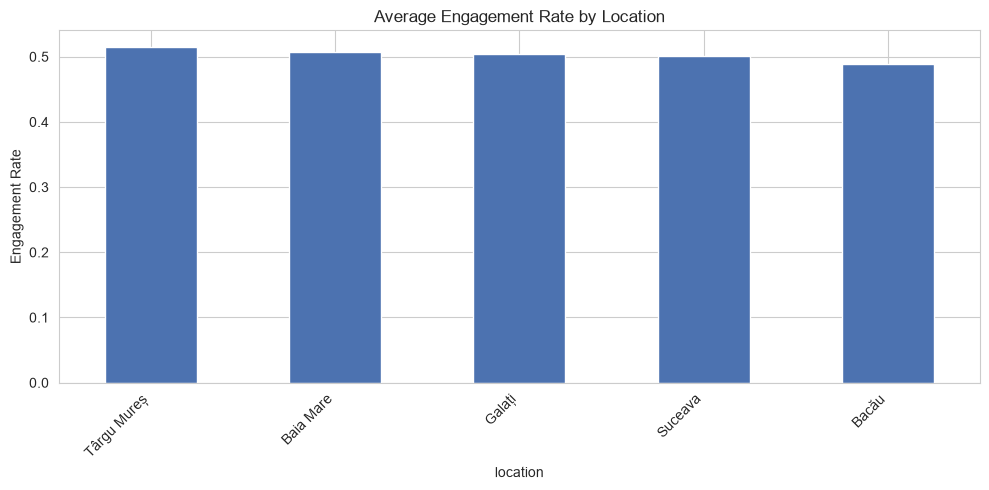

In [16]:
if df_camp is not None:
    avg_engagement_by_location = df_camp.groupby("location")["engagement_rate"].mean().round(4).sort_values(ascending=False)
    print(avg_engagement_by_location)

    plt.figure()
    avg_engagement_by_location.plot(kind="bar", color="#4C72B0")
    plt.title("Average Engagement Rate by Location")
    plt.ylabel("Engagement Rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Q9. Kis age group ki engagement sabse zyada hai? (campaign data se)

age_group
35-44    0.5268
18-24    0.5087
25-34    0.5045
55+      0.4970
45-54    0.4814
Name: engagement_rate, dtype: float64
Sabse zyada engagement wala age group: 35-44


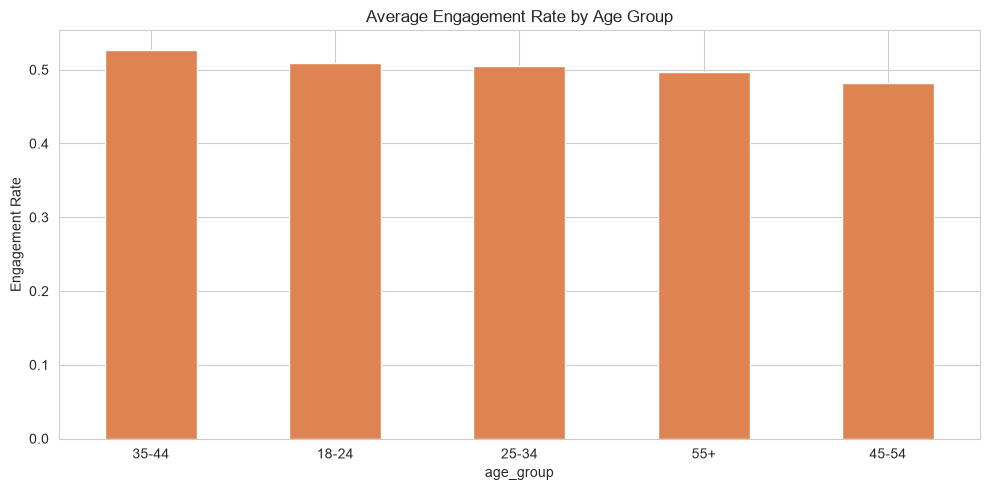

In [17]:
if df_camp is not None:
    engagement_by_age_group = df_camp.groupby("age_group")["engagement_rate"].mean().round(4).sort_values(ascending=False)
    print(engagement_by_age_group)
    top_age_group = engagement_by_age_group.idxmax()
    print(f"Sabse zyada engagement wala age group: {top_age_group}")

    plt.figure()
    engagement_by_age_group.plot(kind="bar", color="#DD8452")
    plt.title("Average Engagement Rate by Age Group")
    plt.ylabel("Engagement Rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Q10. Kya male aur female customers ki average ratings mein difference hai?

In [18]:
if df_cust is not None:
    rating_by_gender = df_cust.groupby("gender")["avg_rating"].agg(["mean", "std", "count"]).round(2)
    print(rating_by_gender)

    plt.figure()
    sns.boxplot(data=df_cust, x="gender", y="avg_rating", palette="Set2")
    plt.title("Rating Distribution: Male vs Female")
    plt.tight_layout()
    plt.show()

    diff = rating_by_gender["mean"].max() - rating_by_gender["mean"].min()
    print(f"Average rating difference between genders: {diff:.2f}")


# Product Analysis

Is data mein individual product names nahi hain. Sabse close proxy campaign_name hai (sirf ~6 categories). Is poore section mein "Top 10 Products" ki jagah campaign/category-level answer diya gaya hai.

Q11. Sabse zyada purchase (conversions) hone wale top campaigns/categories

In [19]:
if df_camp is not None:
    top_by_conversions = df_camp.groupby("campaign_name")["conversions"].sum().sort_values(ascending=False)
    print(top_by_conversions.head(10))


campaign_name
Wishlist Wonders     3700214.4
Cart to Couch        3502488.0
Deal of the Day      3428065.6
Shop & Share         3325440.0
Flash Sale Frenzy    3163931.2
Seasonal Steals      3135513.6
Name: conversions, dtype: float64


Q12. Sabse zyada reviews kis product ko mile hain? (review count column available nahi hai, sirf avg_rating hai — is liye membership type ke hisaab se items purchased dikha rahe hain)

In [20]:
if df_cust is not None:
    print(df_cust.groupby("membership_type")["items_purchased"].sum().sort_values(ascending=False))


Q13. Sabse zyada engagement wale top campaigns/categories

campaign_name
Wishlist Wonders     0.519085
Seasonal Steals      0.514949
Cart to Couch        0.505587
Deal of the Day      0.499568
Shop & Share         0.490224
Flash Sale Frenzy    0.488186
Name: engagement_rate, dtype: float64


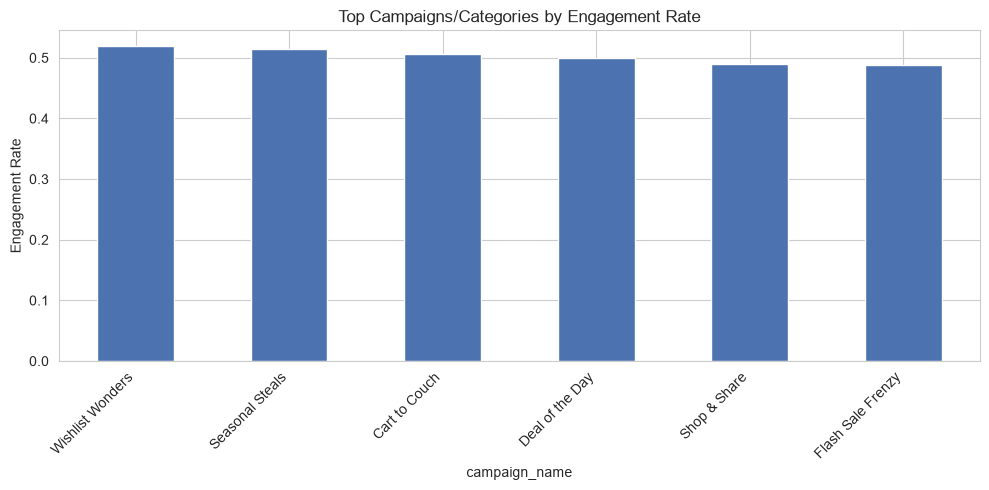

In [21]:
if df_camp is not None:
    top_engagement = df_camp.groupby("campaign_name")["engagement_rate"].mean().sort_values(ascending=False)
    print(top_engagement.head(10))

    plt.figure()
    top_engagement.head(10).plot(kind="bar", color="#4C72B0")
    plt.title("Top Campaigns/Categories by Engagement Rate")
    plt.ylabel("Engagement Rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Q14. Har product category ki average rating (campaign dataset mein rating nahi hai, isliye membership_type ki avg rating dikha rahe hain as similar grouping)

In [22]:
if df_cust is not None:
    avg_rating_by_membership = df_cust.groupby("membership_type")["avg_rating"].mean().round(2).sort_values(ascending=False)
    print(avg_rating_by_membership)


Q15. Har category ki average engagement

In [23]:
if df_camp is not None:
    avg_engagement_by_category = df_camp.groupby("campaign_name")["engagement_rate"].mean().round(4).sort_values(ascending=False)
    print(avg_engagement_by_category)


campaign_name
Wishlist Wonders     0.5191
Seasonal Steals      0.5149
Cart to Couch        0.5056
Deal of the Day      0.4996
Shop & Share         0.4902
Flash Sale Frenzy    0.4882
Name: engagement_rate, dtype: float64


Q16. Har category ki average views aur clicks compare karein

                     views   clicks
campaign_name                      
Cart to Couch      39332.7  19887.0
Deal of the Day    40602.4  20750.6
Flash Sale Frenzy  39953.7  19219.9
Seasonal Steals    41661.1  20728.6
Shop & Share       40272.8  19895.6
Wishlist Wonders   39001.4  20372.3


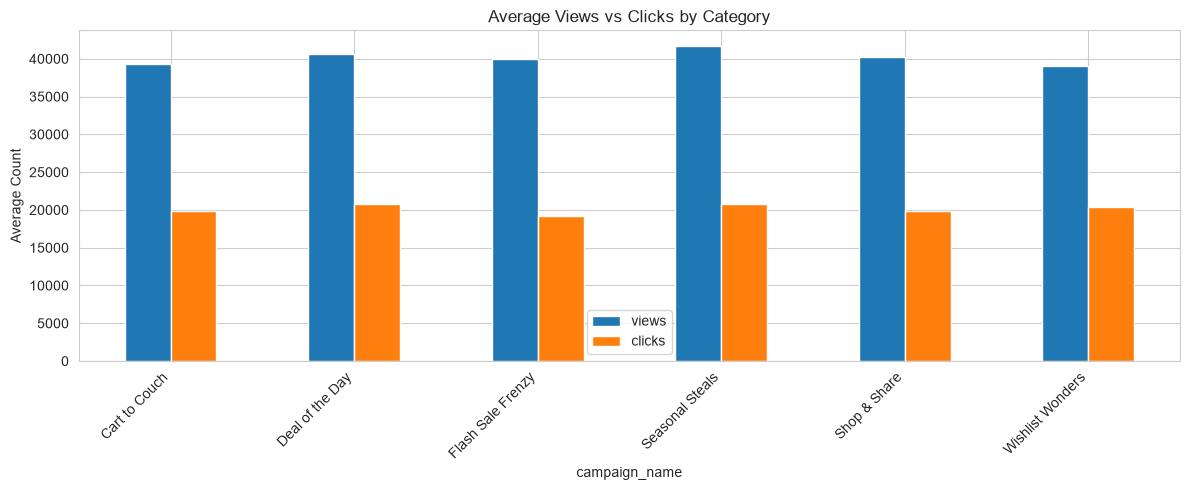

In [24]:
if df_camp is not None:
    views_clicks_by_category = df_camp.groupby("campaign_name")[["views", "clicks"]].mean().round(1)
    print(views_clicks_by_category)

    views_clicks_by_category.plot(kind="bar", figsize=(12, 5))
    plt.title("Average Views vs Clicks by Category")
    plt.ylabel("Average Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Q17 & Q18. Lowest / Highest rated top 10 products (product-level rating available nahi hai, customer-level example diya gaya hai)

In [25]:
if df_cust is not None:
    print("Top 10 highest avg_rating customers:")
    print(df_cust.nlargest(10, "avg_rating")[["customer_id", "avg_rating"]])

    print("Top 10 lowest avg_rating customers:")
    print(df_cust.nsmallest(10, "avg_rating")[["customer_id", "avg_rating"]])


Q19. Kis category mein views zyada hain lekin purchases kam hain?

In [26]:
if df_camp is not None:
    cat_summary = df_camp.groupby("campaign_name")[["views", "conversions"]].sum()
    cat_summary.columns = ["total_views", "total_conversions"]
    cat_summary["conversion_rate"] = cat_summary["total_conversions"] / cat_summary["total_views"]
    low_conversion = cat_summary.sort_values("conversion_rate").head(5)
    print(low_conversion)


                   total_views  total_conversions  conversion_rate
campaign_name                                                     
Flash Sale Frenzy   13384473.6          3163931.2         0.236388
Seasonal Steals     12831612.8          3135513.6         0.244358
Deal of the Day     13764200.0          3428065.6         0.249057
Cart to Couch       13569795.2          3502488.0         0.258109
Wishlist Wonders    14157497.6          3700214.4         0.261361


Q20. Product/category popularity bar chart

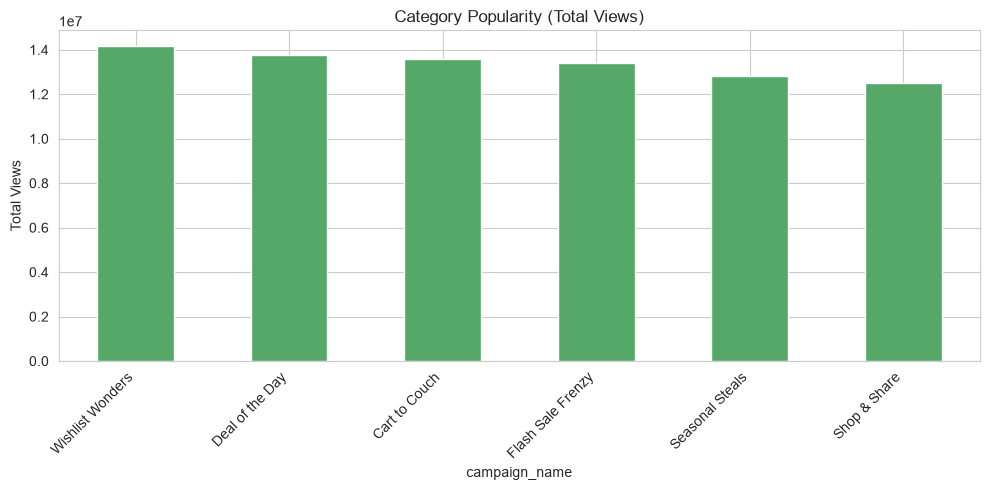

In [27]:
if df_camp is not None:
    popularity = df_camp.groupby("campaign_name")["views"].sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    popularity.plot(kind="bar", color="#55A868")
    plt.title("Category Popularity (Total Views)")
    plt.ylabel("Total Views")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Engagement Analysis

Likes column available nahi hai, is section mein skip kiya gaya hai. Views = Impressions, Purchases = Conversions.

Q21. Total Views, Total Clicks

In [28]:
if df_camp is not None:
    total_views = df_camp["views"].sum()
    total_clicks = df_camp["clicks"].sum()
    print(f"Total Views: {total_views:,.0f}")
    print(f"Total Clicks: {total_clicks:,.0f}")
    print("Total Likes: not available in this dataset")


Total Views: 80,192,134
Total Clicks: 40,281,338
Total Likes: not available in this dataset


Q22. Overall Engagement Rate

In [29]:
if df_camp is not None:
    overall_engagement_rate = df_camp["clicks"].sum() / df_camp["views"].sum()
    print(f"Overall Engagement Rate: {overall_engagement_rate:.4f} ({overall_engagement_rate*100:.2f}%)")


Overall Engagement Rate: 0.5023 (50.23%)


Q23. Har campaign/category ka Engagement Rate compare karein

In [30]:
if df_camp is not None:
    engagement_by_campaign = df_camp.groupby("campaign_id")["engagement_rate"].mean().sort_values(ascending=False)
    print(engagement_by_campaign)


campaign_id
CMP240     0.999793
CMP527     0.999624
CMP212     0.999529
CMP818     0.999408
CMP1841    0.998897
             ...   
CMP942     0.008539
CMP1636    0.008361
CMP1609    0.007445
CMP87      0.006751
CMP1292    0.004316
Name: engagement_rate, Length: 2000, dtype: float64


Q24. Sabse zyada viewed aur sabse zyada clicked campaigns

In [31]:
if df_camp is not None:
    most_viewed = df_camp.loc[df_camp["views"].idxmax()]
    most_clicked = df_camp.loc[df_camp["clicks"].idxmax()]

    print("Most Viewed Campaign:")
    print(most_viewed[["campaign_id", "campaign_name", "views"]])
    print("Most Clicked Campaign:")
    print(most_clicked[["campaign_id", "campaign_name", "clicks"]])


Most Viewed Campaign:
campaign_id              CMP1208
campaign_name    Deal of the Day
views                    79894.4
Name: 1207, dtype: object
Most Clicked Campaign:
campaign_id              CMP1866
campaign_name    Deal of the Day
clicks                   77414.4
Name: 1865, dtype: object


Q25. Least engaged campaigns/categories

In [32]:
if df_camp is not None:
    least_engaged = df_camp.groupby("campaign_id")["engagement_rate"].mean().sort_values().head(5)
    print(least_engaged)


campaign_id
CMP1292    0.004316
CMP87      0.006751
CMP1609    0.007445
CMP1636    0.008361
CMP942     0.008539
Name: engagement_rate, dtype: float64


Q26. Monthly conversion trend

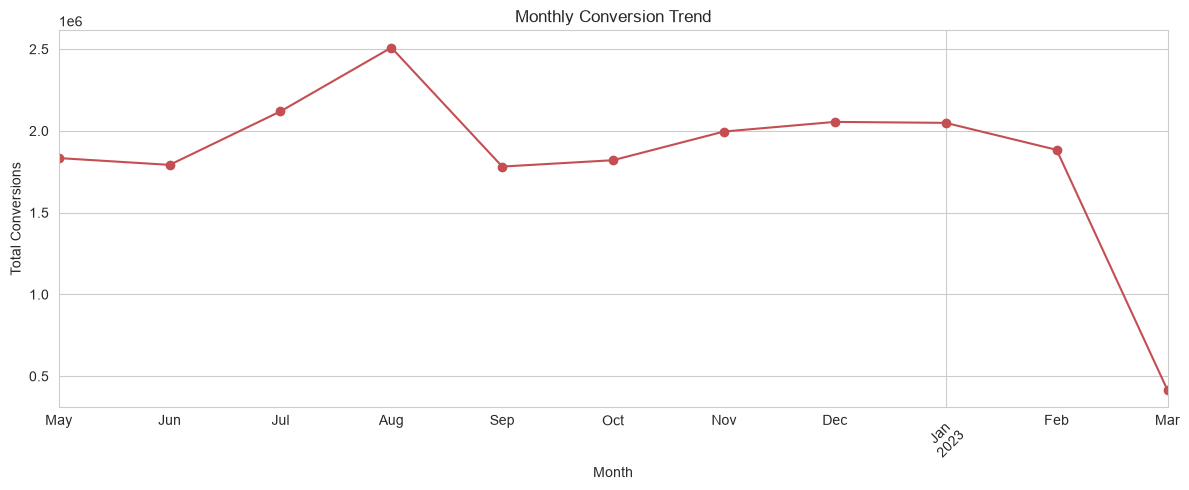

In [33]:
if df_camp is not None and "start_date" in df_camp.columns:
    monthly_trend = df_camp.dropna(subset=["start_date"]).copy()
    monthly_trend["start_month"] = monthly_trend["start_date"].dt.to_period("M")
    monthly_conversions = monthly_trend.groupby("start_month")["conversions"].sum()

    plt.figure(figsize=(12, 5))
    monthly_conversions.plot(kind="line", marker="o", color="#C44E52")
    plt.title("Monthly Conversion Trend")
    plt.ylabel("Total Conversions")
    plt.xlabel("Month")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Q27. Har campaign ka CTR calculate karein

In [34]:
if df_camp is not None:
    ctr_by_campaign = df_camp.groupby("campaign_id")["ctr_percent"].mean().round(2).sort_values(ascending=False)
    print(ctr_by_campaign)


campaign_id
CMP240     99.98
CMP527     99.96
CMP212     99.95
CMP818     99.94
CMP1841    99.89
           ...  
CMP942      0.85
CMP1636     0.84
CMP1609     0.74
CMP87       0.68
CMP1292     0.43
Name: ctr_percent, Length: 2000, dtype: float64


Q28. Top performing aur lowest performing campaigns

In [35]:
if df_camp is not None:
    campaign_performance = df_camp.groupby(["campaign_id", "campaign_name"]).agg({
        "ctr_percent": "mean",
        "conversions": "sum",
        "revenue": "sum"
    })
    campaign_performance.columns = ["avg_ctr", "total_conversions", "total_revenue"]
    campaign_performance = campaign_performance.sort_values("total_revenue", ascending=False)

    print("Top 5 performing campaigns:")
    print(campaign_performance.head(5))

    print("Lowest 5 performing campaigns:")
    print(campaign_performance.tail(5))


Top 5 performing campaigns:
                                avg_ctr  total_conversions  total_revenue
campaign_id campaign_name                                                
CMP432      Deal of the Day   48.922787             6329.6      31791.344
CMP1411     Seasonal Steals   13.097624             1160.0      31609.728
CMP177      Shop & Share      24.213389              937.6      30883.136
CMP1195     Wishlist Wonders  53.938531             8880.0      30796.960
CMP371      Deal of the Day   14.949299             8209.6      30676.000
Lowest 5 performing campaigns:
                                avg_ctr  total_conversions  total_revenue
campaign_id campaign_name                                                
CMP248      Deal of the Day   56.145647             7769.6        340.400
CMP410      Seasonal Steals   15.172414             3028.8        319.312
CMP872      Seasonal Steals   60.179934             9171.2        290.592
CMP1863     Wishlist Wonders  51.806876             1

# Combined Analysis

Dono datasets mein common ID nahi hai, isliye row-by-row merge possible nahi. Gender aur Age Group par group karke merge kiya gaya hai — yeh group-level approximation hai.

In [36]:
if df_cust is not None and df_camp is not None:
    print("Age Group categories in campaign dataset:", sorted(df_camp["age_group"].dropna().unique().tolist()))

    # Customer dataset ke Age column ko usi tarah ke groups mein daal rahe hain
    # taake dono datasets Gender + Age Group par merge ho sakein.
    # Agar upar wali list se bins match na karein, yahan values adjust kar lena.
    bins = [17, 24, 34, 44, 54, 200]
    labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
    df_cust["age_group"] = pd.cut(df_cust["age"], bins=bins, labels=labels)
    print("Customer dataset ko diye gaye age_group labels:", labels)


Q29. Engagement aur ratings ke darmiyan relationship — scatter plot aur correlation

In [37]:
if df_cust is not None and df_camp is not None:
    cust_agg = df_cust.groupby(["gender", "age_group"])[["avg_rating", "total_spend", "items_purchased"]].mean().reset_index()
    cust_agg.columns = ["gender", "age_group", "avg_rating", "avg_spend", "avg_items"]
    cust_agg = cust_agg.dropna()

    camp_agg = df_camp.groupby(["gender", "age_group"])[["engagement_rate", "views", "clicks", "conversions", "revenue"]].mean().reset_index()
    camp_agg.columns = ["gender", "age_group", "avg_engagement", "avg_views", "avg_clicks", "avg_conversions", "avg_revenue"]
    camp_agg = camp_agg.dropna()

    merged = pd.merge(cust_agg, camp_agg, on=["gender", "age_group"], how="inner")
    print(f"Merged group-level table: {merged.shape[0]} groups")
    display(merged)

    plt.figure()
    sns.scatterplot(data=merged, x="avg_engagement", y="avg_rating", hue="gender", s=120)
    plt.title("Engagement Rate vs Average Rating")
    plt.xlabel("Average Engagement Rate")
    plt.ylabel("Average Rating")
    plt.tight_layout()
    plt.show()

    corr_value = merged["avg_engagement"].corr(merged["avg_rating"])
    print(f"Correlation between Engagement Rate and Rating: {corr_value:.3f}")


Q30. Correlation Matrix (Heatmap) — Views, Clicks, Rating, Purchase, etc. (Likes aur Duration is data mein nahi hain, isliye exclude kiye gaye hain)

In [38]:
if df_cust is not None and df_camp is not None:
    corr_columns = ["avg_rating", "avg_spend", "avg_items", "avg_engagement", "avg_views", "avg_clicks", "avg_conversions", "avg_revenue"]
    corr_matrix = merged[corr_columns].corr().round(2)

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    print(corr_matrix)
